In [1]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_parquet("../../../data/Train/datos_holding_upsampled.parquet")
# df = pd.read_parquet("../../../data/Train/datos_holding_with_runway.parquet")

df

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue,timestamp,tiempo_esperado
0,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,97.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11,2025-01-01 11:28:40.463,0.0
1,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,92.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11,2025-01-01 11:28:45.463,5.0
2,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,87.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11,2025-01-01 11:28:50.463,10.0
3,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,82.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11,2025-01-01 11:28:55.463,15.0
4,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,77.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11,2025-01-01 11:29:00.463,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171132,4ca621,2024-12-26 12:01:45.912,2024-12-26 12:02:03.896,2024-12-26 12:03:37.060,21.148,Medium 2 (between 34000 kg to 136000 kg),-3.561225,40.499446,-3.560101,40.499621,Y1,False,18L/36R,2024-12-26,12,2024-12-26 12:03:15.912,90.0
1171133,4ca621,2024-12-26 12:01:45.912,2024-12-26 12:02:03.896,2024-12-26 12:03:37.060,16.148,Medium 2 (between 34000 kg to 136000 kg),-3.561225,40.499446,-3.560101,40.499621,Y1,False,18L/36R,2024-12-26,12,2024-12-26 12:03:20.912,95.0
1171134,4ca621,2024-12-26 12:01:45.912,2024-12-26 12:02:03.896,2024-12-26 12:03:37.060,11.148,Medium 2 (between 34000 kg to 136000 kg),-3.561225,40.499446,-3.560101,40.499621,Y1,False,18L/36R,2024-12-26,12,2024-12-26 12:03:25.912,100.0
1171135,4ca621,2024-12-26 12:01:45.912,2024-12-26 12:02:03.896,2024-12-26 12:03:37.060,6.148,Medium 2 (between 34000 kg to 136000 kg),-3.561225,40.499446,-3.560101,40.499621,Y1,False,18L/36R,2024-12-26,12,2024-12-26 12:03:30.912,105.0


(array([2.65250e+05, 1.88923e+05, 7.21800e+04, 2.21730e+04, 7.75100e+03,
        3.89100e+03, 2.23600e+03, 1.47400e+03, 7.43000e+02, 2.56000e+02]),
 array([  0.    ,  49.8518,  99.7036, 149.5554, 199.4072, 249.259 ,
        299.1108, 348.9626, 398.8144, 448.6662, 498.518 ]),
 <BarContainer object of 10 artists>)

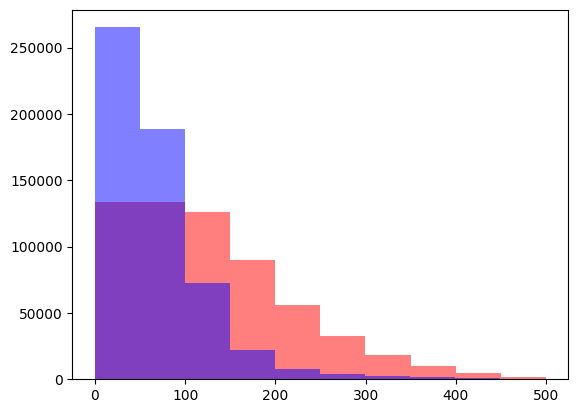

In [2]:
import matplotlib.pyplot as plt
plt.hist(df[df["parado"]==True]["tiempo_espera"], color="red", alpha=0.5, label="parado") 
plt.hist(df[df["parado"]==False]["tiempo_espera"], color="blue", alpha=0.5, label="no parado")

In [3]:
df.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue', 'timestamp', 'tiempo_esperado'],
      dtype='object')

In [4]:
import pandas as pd
import numpy as np

def procesar_datos(df):
    df = df.copy()

    # --- Timestamps ---
    df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"], errors="coerce")

    # # Hora en segundos desde medianoche
    # df["segundos_llegada"] = df["timestamp"].dt.hour * 3600 + df["timestamp"].dt.minute * 60 + df["timestamp"].dt.second

    # Día de la semana (0=lunes, 6=domingo)
    df["dia_semana"] = df["fecha_despegue"].dt.weekday

    # Codificar si es fin de semana
    #df["es_finde"] = df["dia_semana"] >= 5

    # --- Categóricas como one-hot ---
    df = pd.get_dummies(df, columns=["aircraft_type", "holding_point"], drop_first=True)

    # --- Booleanas ---
    #df["parado"] = df["parado"].astype(int)
    #df["es_finde"] = df["es_finde"].astype(int)

    # --- Variables finales ---
    columnas_finales = ["tiempo_esperado", "dia_semana", "hora_despegue"] + \
                       [col for col in df.columns if col.startswith("aircraft_type_") or col.startswith("holding_point_")]

    x = df[columnas_finales].values.astype(np.float32)
    y = df["tiempo_espera"].values.astype(np.float32)

    umbral = 1000  # segundos
    mask = y < umbral

    x = x[mask]
    y = y[mask]

    mask = y > 0
    x = x[mask]
    y = y[mask]

    return x, y, columnas_finales

In [5]:
df = df[df["parado"]  == True]
x, y, columnas = procesar_datos(df)

In [6]:
columnas

['tiempo_esperado',
 'dia_semana',
 'hora_despegue',
 'aircraft_type_High vortex aircraft',
 'aircraft_type_Light (less than 7000 kg)',
 'aircraft_type_Medium 1 (between 7000 kg and 34000 kg)',
 'aircraft_type_Medium 2 (between 34000 kg to 136000 kg)',
 'holding_point_K2',
 'holding_point_K3',
 'holding_point_L1',
 'holding_point_LA',
 'holding_point_LB',
 'holding_point_LC',
 'holding_point_LD',
 'holding_point_LE',
 'holding_point_Y1',
 'holding_point_Y2',
 'holding_point_Y3',
 'holding_point_Z1',
 'holding_point_Z2',
 'holding_point_Z3',
 'holding_point_Z4']

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

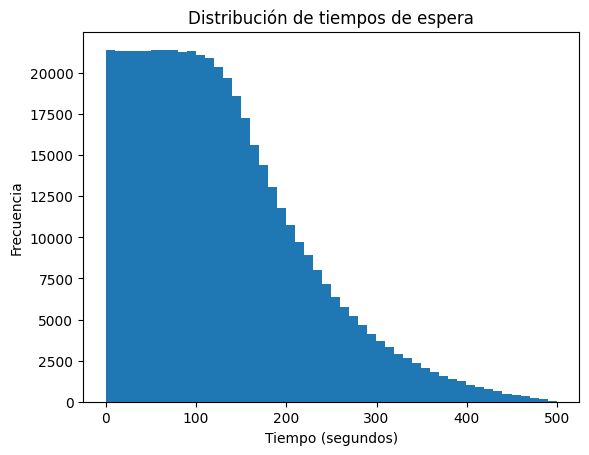

In [8]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50)
plt.title("Distribución de tiempos de espera")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Frecuencia")
plt.show()

In [9]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

def modelo_regresion(x, y=None):
    n_features = x.shape[1]

    # Priores para los coeficientes y bias
    beta = numpyro.sample("beta", dist.Normal(0, 1).expand([n_features]))
    intercept = numpyro.sample("intercept", dist.Normal(0, 5))
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))  # escala del LogNormal

    # Predicción media (log del tiempo esperado)
    mu = intercept + jnp.dot(x, beta)

    # Tiempo de espera ~ LogNormal(mu, sigma)
    numpyro.sample("obs", dist.LogNormal(mu, sigma), obs=y)

In [ ]:
from numpyro.infer import MCMC, NUTS

rng_key = jax.random.PRNGKey(0)
kernel = NUTS(modelo_regresion)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000)
mcmc.run(rng_key, x=x_train, y=y_train)
mcmc.print_summary()

TypeError: MCMC.__init__() missing 1 required keyword-only argument: 'num_warmup'

In [ ]:
from numpyro.infer import Predictive

# Predictive posterior
predictive = Predictive(modelo_regresion, posterior_samples=mcmc.get_samples(), return_sites=["obs"])
preds = predictive(jax.random.PRNGKey(1), x=x_test)

# Media y percentiles
y_pred_mean = jnp.mean(preds["obs"], axis=0)
y_pred_lower = jnp.percentile(preds["obs"], 5, axis=0)
y_pred_upper = jnp.percentile(preds["obs"], 95, axis=0)

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_mean)
print("MAE:", mae)

# Opcional: imprimir algunos intervalos de confianza
for i in range(5):
    print(f"Ejemplo {i}: predicho {y_pred_mean[i]:.1f}s (95% CI: {y_pred_lower[i]:.1f} - {y_pred_upper[i]:.1f}), real: {y_test[i]:.1f}s")


MAE: 1973.9970703125
Ejemplo 0: predicho 236.0s (95% CI: 4.7 - 1000.9), real: 173.4s
Ejemplo 1: predicho 976.7s (95% CI: 10.6 - 2704.6), real: 336.6s
Ejemplo 2: predicho 217.3s (95% CI: 3.3 - 756.4), real: 267.9s
Ejemplo 3: predicho 1506.2s (95% CI: 18.6 - 4924.4), real: 307.0s
Ejemplo 4: predicho 908.0s (95% CI: 16.2 - 3428.0), real: 257.2s


In [ ]:
# import jax.numpy as jnp
# import numpyro
# import numpyro.distributions as dist

# def modelo_aviones(x, punto_id, y_obs=None, num_puntos=5, num_pistas=3):
#     N, D = x.shape  # N datos, D variables

#     # Priori para probabilidades de pistas por punto de espera (categorical prior)
#     with numpyro.plate("puntos", num_puntos):
#         pi = numpyro.sample("pi", dist.Dirichlet(jnp.ones(num_pistas)))

#     # Intercepto por punto de espera
#     with numpyro.plate("alpha_puntos", num_puntos):
#         alpha = numpyro.sample("alpha", dist.Normal(0, 1))

#     # Efecto por pista (latente)
#     with numpyro.plate("pistas", num_pistas):
#         gamma = numpyro.sample("gamma", dist.Normal(0, 1))

#     # Coeficientes para covariables
#     beta = numpyro.sample("beta", dist.Normal(0, 1).expand([D]))

#     # Desviación estándar
#     sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))

#     with numpyro.plate("datos", N):
#         # Variable latente: pista asignada
#         z = numpyro.sample("z", dist.Categorical(probs=pi[punto_id]))

#         # Media para cada observación
#         mu = alpha[punto_id] + gamma[z] + jnp.sum(x * beta, axis=1)

#         # Modelo del tiempo de espera
#         numpyro.sample("obs", dist.LogNormal(mu, sigma), obs=y_obs)


In [ ]:
# from numpyro.infer import MCMC, NUTS
# import jax.random as random

# # Supongamos que ya tienes: x, punto_id, y_obs
# # x: (N, D), punto_id: (N,), y_obs: (N,)
# rng_key = random.PRNGKey(0)

# kernel = NUTS(modelo_aviones)
# mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000)
# mcmc.run(rng_key, x=x, punto_id=punto_id, y_obs=y_obs,
#          num_puntos=num_puntos, num_pistas=num_pistas)

# samples = mcmc.get_samples()

In [ ]:
# import numpyro.infer

# # Ejemplo: para nuevos datos x_test y punto_id_test
# predictive = numpyro.infer.Predictive(
#     modelo_aviones, posterior_samples=samples, return_sites=["obs", "z"]
# )

# preds = predictive(rng_key, x=x_test, punto_id=punto_id_test,
#                    num_puntos=num_puntos, num_pistas=num_pistas)